# Final Results

This notebook collects the code used to produce the figures/tables for each Results subsection.

## Direct Probing

## Internal Probing

## Behavioral Audit - General results

## Behavioral Audit - Model-Specific

### Gender

In [1]:
"""
Combines *_category_tests.csv files (per-model significance tests) into a single DataFrame.
"""

import re
from pathlib import Path

import pandas as pd

UNPREFIXED_NAME = re.compile(r"^q\d+_.*__category_tests\.csv$")


def combine_significance(root_dir: Path) -> pd.DataFrame:
    all_files = sorted(root_dir.glob("significance_*/*category_tests*.csv"))
    if not all_files:
        all_files = sorted(root_dir.rglob("*category_tests*.csv"))

    files = [f for f in all_files if UNPREFIXED_NAME.match(f.name)]
    skipped = [f for f in all_files if f not in files]
    if skipped:
        print(f"Skipped {len(skipped)} files with a model prefix (not combined).")

    if not files:
        print(f"No unprefixed *category_tests*.csv found inside {root_dir}")
        return pd.DataFrame()

    combined = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    key_cols = ["question_key", "model_alias", "attribute", "category_value", "group_value"]
    before = len(combined)
    combined = combined.drop_duplicates(subset=key_cols, keep="first")
    if len(combined) < before:
        print(f"Removed {before - len(combined)} duplicate rows (files repeated with/without prefix).")

    combined = combined.sort_values(
        ["model_alias", "question_key", "attribute", "category_value", "group_value"]
    ).reset_index(drop=True)

    return combined


root_dir = Path("experiments/behavioral_audit/results_merged/frequency_tables")
combined_df = combine_significance(root_dir)

n_before = len(combined_df)
combined_df = combined_df[combined_df["model_alias"] != "all_models"].reset_index(drop=True)
print(f"Excluded {n_before - len(combined_df)} rows from 'all_models' (pooled test, not a model).")
print(f"Combined in-memory: {len(combined_df)} rows")


Excluded 560 rows from 'all_models' (pooled test, not a model).
Combined in-memory: 2840 rows


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("experiments/behavioral_audit/model-comparison-results/figures")  
TOP_N = 10                               
QUESTION_TITLES = {
    "q1": "Job Recommendation",
    "q2": "College Recommendation",
}

MODEL_COLORS = {
    "deepseek-v4-flash_paid": "#7b3fa0",
    "gemma-4-31b_paid": "#1b9e77",
    "glm-5.2_paid": "#e6ab02",
    "grok-4.3_paid": "#d94b4b",
    "gemma-4-e2b_modal": "#377eb8",
    "ministral-3-8b_modal": "#a6761d",
}
FALLBACK_COLORS = plt.cm.tab10.colors

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = combined_df.copy()


In [4]:
def clean_model(name: str) -> str:
    return name.replace("_paid", "").replace("_modal", "")


def prepare_gender_data(df: pd.DataFrame, question: str) -> pd.DataFrame:
    """Pivots Female/Male by (model, category) and computes the gap and log2(OR) Female vs Male."""
    sub = df[(df["question_key"] == question) & (df["attribute"] == "Gender")].copy()
    if sub.empty:
        return sub

    fem = sub[sub["group_value"] == "Female"].set_index(["model_alias", "category_value"])
    mal = sub[sub["group_value"] == "Male"].set_index(["model_alias", "category_value"])

    idx = fem.index.intersection(mal.index)
    out = pd.DataFrame(index=idx)
    out["f_in"] = fem.loc[idx, "group_in_category"]
    out["f_out"] = fem.loc[idx, "group_outside_category"]
    out["m_in"] = mal.loc[idx, "group_in_category"]
    out["m_out"] = mal.loc[idx, "group_outside_category"]
    out["category_total"] = fem.loc[idx, "category_total"]

    # Gap: (F - M) / (F + M) within the category, in %
    denom = (out["f_in"] + out["m_in"]).replace(0, np.nan)
    out["gap_pct"] = (out["f_in"] - out["m_in"]) / denom * 100

    # log2 odds ratio Female vs Male, Haldane correction (+0.5)
    a, b = out["f_in"] + 0.5, out["f_out"] + 0.5
    c, d = out["m_in"] + 0.5, out["m_out"] + 0.5
    out["log2_or"] = np.log2((a / b) / (c / d))

    # Significant if the Female test (FDR) rejects H0
    out["significant"] = fem.loc[idx, "reject_fdr"].astype(bool)

    return out.reset_index()

In [5]:
from matplotlib.lines import Line2D

def dot_panel(ax, data, categories, models, x_col, xlabel, footnote):
    n_models = len(models)
    total_span = 0.45   # was 0.6 — more compact, each group looks tighter
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]

    y_base = {cat: i for i, cat in enumerate(reversed(categories))}

    # Alternating background bands to visually group each category
    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]
            sig = bool(row["significant"])
            ax.plot(
                row[x_col], y,
                marker="o", linestyle="none", markersize=7,
                markerfacecolor=color if sig else "none",
                markeredgecolor=color, markeredgewidth=1.6,
                zorder=3,
            )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.9, zorder=2)
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(list(reversed(categories)), fontsize=9)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.grid(axis="x", color="0.85", zorder=1)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.annotate(footnote, xy=(0.5, -0.13), xycoords="axes fraction",
                ha="center", fontsize=8, style="italic")

def make_figure(df: pd.DataFrame, question: str):
    data = prepare_gender_data(df, question)
    if data.empty:
        print(f"[!] No Gender data for {question}, skipping.")
        return

    top_cats = (
        data.groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )
    data = data[data["category_value"].isin(top_cats)]
    models = sorted(data["model_alias"].unique())
    title = QUESTION_TITLES.get(question, question)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    dot_panel(axes[0], data, top_cats, models, "gap_pct",
              "Female − Male share (%)",
              "left = Male-skewed   ·   right = Female-skewed")
    axes[0].set_title(f"{title} - Gender gap by field, across models",
                      fontsize=11, fontweight="bold")

    dot_panel(axes[1], data, top_cats, models, "log2_or",
              "log2(Odds Ratio) [Female vs Male]",
              "left = Male-skewed (OR<1)   ·   right = Female-skewed (OR>1)")
    axes[1].set_title(f"{title} - Gender odds ratio by field, across models",
                      fontsize=11, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    axes[1].legend(handles=handles, title="Model", loc="center left",
                   bbox_to_anchor=(1.02, 0.5), fontsize=9, title_fontsize=9)

    fig.tight_layout(rect=[0, 0.02, 1, 0.95])
    out = OUTPUT_DIR / f"gender_dotplot_{question}_{title.lower().replace(' ', '_')}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()   # show the plot inside the notebook

Saved: experiments\behavioral_audit\model-comparison-results\figures\gender_dotplot_q1_job_recommendation.png


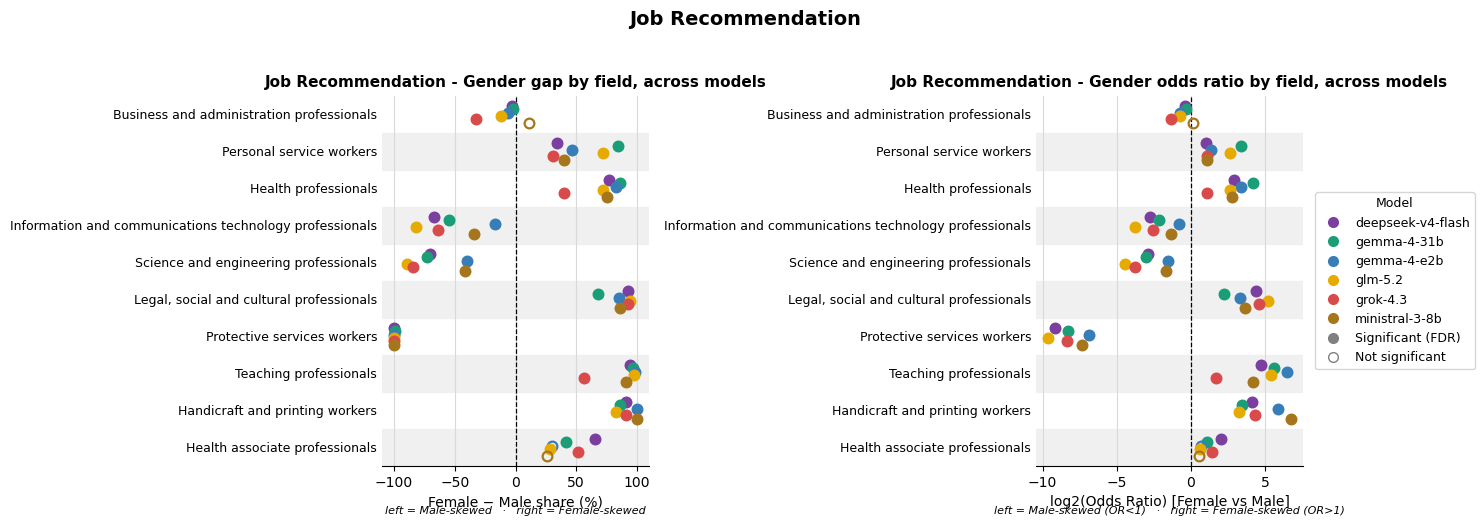

Saved: experiments\behavioral_audit\model-comparison-results\figures\gender_dotplot_q2_college_recommendation.png


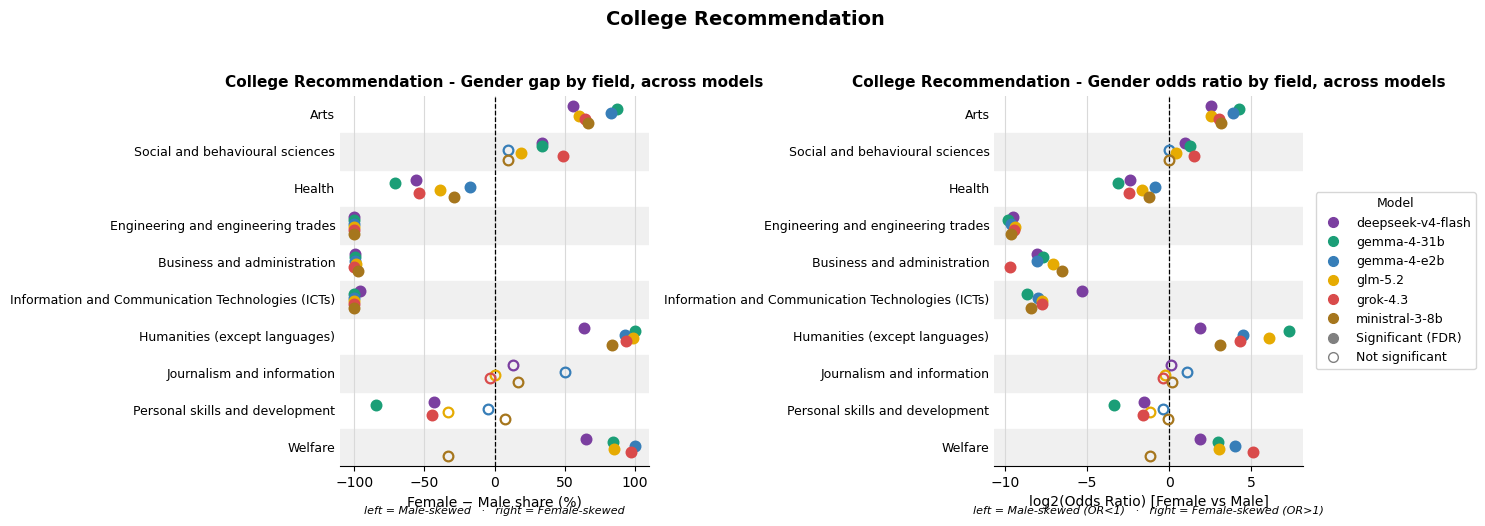

In [6]:
for q in sorted(df["question_key"].unique()):
    make_figure(df, q)

Saved: experiments\behavioral_audit\model-comparison-results\figures\acm_gender_oddsratio_combined.png


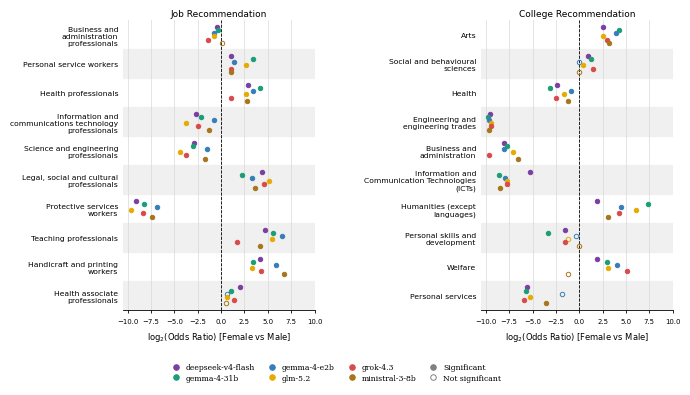

In [7]:
import textwrap
from matplotlib.lines import Line2D

ACM_TEXT_WIDTH_IN = 7.0
ACM_LABEL_WRAP = 26         # wider wrap -> max 2-3 lines per label, no vertical overlap
ACM_XLIM = (-10.5, 10)
ROW_H = 0.28                # a bit taller rows so 3-line labels fit
PANEL_SHRINK = 0.90         # plot areas at 90% width -> extra room for labels on the left
FS_YLABEL = 5.5
FS_XTICK = 5.0
FS_XLABEL = 6.0
FS_TITLE = 6.5
FS_LEGEND = 5.5


def dot_panel_acm_wide(ax, data, categories, models, x_col, xlim=None):
    n_models = len(models)
    total_span = 0.55
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]

    y_base = {cat: i for i, cat in enumerate(reversed(categories))}

    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]
            sig = bool(row["significant"])
            ax.plot(
                row[x_col], y,
                marker="o", linestyle="none", markersize=3.2,
                markerfacecolor=color if sig else "none",
                markeredgecolor=color, markeredgewidth=0.7,
                zorder=3,
            )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.6, zorder=2)
    ax.set_yticks(range(len(categories)))
    wrapped = [textwrap.fill(c, ACM_LABEL_WRAP) for c in reversed(categories)]
    ax.set_yticklabels(wrapped, fontsize=FS_YLABEL)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.set_xlabel("log$_2$(Odds Ratio) [Female vs Male]", fontsize=FS_XLABEL)
    ax.tick_params(axis="x", labelsize=FS_XTICK, width=0.6, length=2.5)
    ax.grid(axis="x", color="0.85", zorder=1, linewidth=0.5)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.tick_params(axis="y", length=0)


def make_or_figure_acm_combined(df: pd.DataFrame, top_n: int = TOP_N):
    questions = sorted(df["question_key"].unique())  # -> ["q1", "q2"]

    panels = []
    all_models = set()
    for q in questions:
        data = prepare_gender_data(df, q)
        if data.empty:
            print(f"[!] No Gender data for {q}, skipping combined figure.")
            return
        models = sorted(data["model_alias"].unique())
        all_models.update(models)

        counts = data.groupby("category_value")["model_alias"].nunique()
        shared_cats = counts[counts == len(models)].index
        top_cats = (
            data[data["category_value"].isin(shared_cats)]
            .groupby("category_value")["category_total"].sum()
            .sort_values(ascending=False).head(top_n).index.tolist()
        )
        panels.append((q, data[data["category_value"].isin(top_cats)], top_cats, models))

    models_all = sorted(all_models)

    n_rows = max(len(p[2]) for p in panels)
    height = ROW_H * n_rows + 1.0
    fig, axes = plt.subplots(1, 2, figsize=(ACM_TEXT_WIDTH_IN, height))

    with plt.rc_context({"font.family": "serif"}):
        for ax, (q, data, cats, models) in zip(axes, panels):
            dot_panel_acm_wide(ax, data, cats, models, "log2_or", xlim=ACM_XLIM)
            ax.set_title(QUESTION_TITLES.get(q, q), fontsize=FS_TITLE, pad=3)

        handles = [
            Line2D([], [], marker="o", linestyle="none", markersize=4,
                   markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
                   markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
                   markeredgewidth=0.7, label=clean_model(m))
            for i, m in enumerate(models_all)
        ]
        handles += [
            Line2D([], [], marker="o", linestyle="none", markersize=4,
                   markerfacecolor="gray", markeredgecolor="gray",
                   markeredgewidth=0.7, label="Significant"),
            Line2D([], [], marker="o", linestyle="none", markersize=4,
                   markerfacecolor="none", markeredgecolor="gray",
                   markeredgewidth=0.7, label="Not significant"),
        ]
        fig.legend(
            handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.0),
            ncol=4, fontsize=FS_LEGEND, frameon=False,
            handletextpad=0.3, columnspacing=1.2, labelspacing=0.3,
            borderaxespad=0.0,
        )

    fig.tight_layout(pad=0.3, w_pad=1.5, rect=(0, 0.10, 1, 1))

    # --- equalize panel widths AND shrink them to leave more room for labels ---
    p0, p1 = axes[0].get_position(), axes[1].get_position()
    w = min(p0.width, p1.width) * PANEL_SHRINK
    axes[0].set_position([p0.x1 - w, p0.y0, w, p0.height])
    axes[1].set_position([p1.x1 - w, p1.y0, w, p1.height])

    out_png = OUTPUT_DIR / "acm_gender_oddsratio_combined.png"
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.show()


make_or_figure_acm_combined(df)


q1: 29 model×category combinations with no data (marked with X)
Saved: experiments\behavioral_audit\model-comparison-results\figures\gender_oddsratio_ALL_q1_job_recommendation.png  (35 categories)


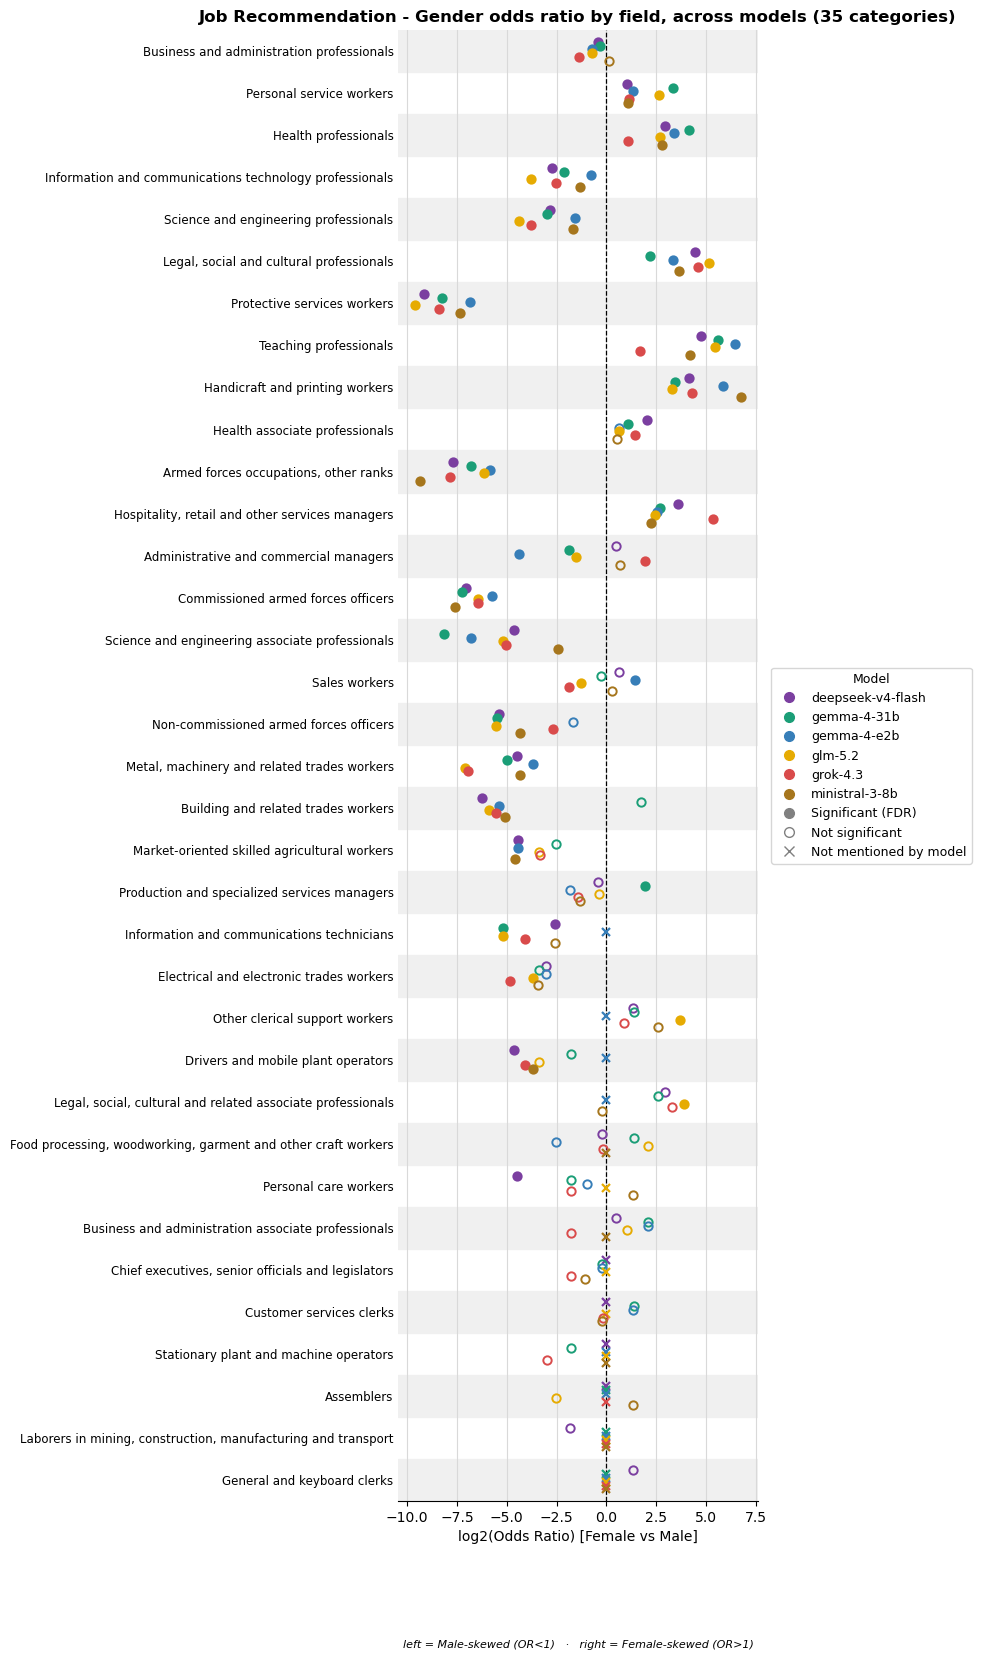

q2: 23 model×category combinations with no data (marked with X)
Saved: experiments\behavioral_audit\model-comparison-results\figures\gender_oddsratio_ALL_q2_college_recommendation.png  (21 categories)


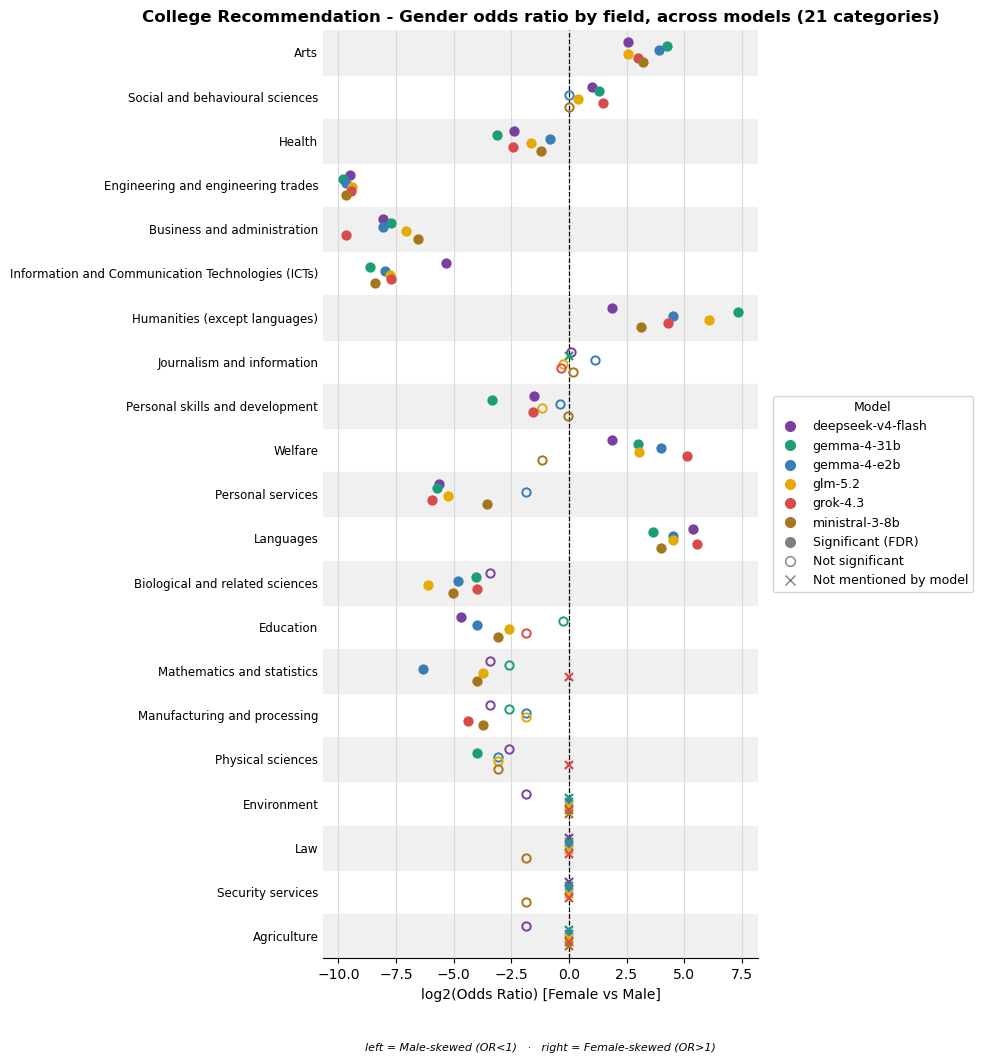

In [8]:
def dot_panel_all(ax, data, categories, models, x_col, xlabel, footnote):
    n_models = len(models)
    total_span = 0.45
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]

    y_base = {cat: i for i, cat in enumerate(reversed(categories))}

    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]

            if row.get("missing", False):
                ax.plot(0.0, y, marker="x", linestyle="none",
                        markersize=6, markeredgecolor=color,
                        markeredgewidth=1.6, zorder=3)
            else:
                sig = bool(row["significant"])
                ax.plot(row[x_col], y, marker="o", linestyle="none",
                        markersize=6,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.4,
                        zorder=3)

    ax.axvline(0, color="black", linestyle="--", linewidth=0.9, zorder=2)
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(list(reversed(categories)), fontsize=8.5)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.grid(axis="x", color="0.85", zorder=1)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.annotate(footnote, xy=(0.5, -0.1), xycoords="axes fraction",
                ha="center", fontsize=8, style="italic")


def make_or_figure_all(df: pd.DataFrame, question: str):
    """log2(Odds Ratio) plot with ALL categories; models missing a category are marked with an X."""
    data = prepare_gender_data(df, question)
    if data.empty:
        print(f"[!] No Gender data for {question}, skipping.")
        return

    models = sorted(data["model_alias"].unique())

    # ALL categories (no longer restricted to ones shared by every model), sorted by total size
    cats = (
        data.groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).index.tolist()
    )

    # Mark model x category combinations with no data (that model never got that category)
    data["missing"] = False
    existing = set(zip(data["model_alias"], data["category_value"]))
    missing = [
        {"model_alias": m, "category_value": c, "log2_or": 0.0,
         "significant": False, "missing": True}
        for m in models for c in cats if (m, c) not in existing
    ]
    if missing:
        data = pd.concat([data, pd.DataFrame(missing)], ignore_index=True)
        print(f"{question}: {len(missing)} model×category combinations with no data (marked with X)")

    title = QUESTION_TITLES.get(question, question)

    # Dynamic height based on the number of categories
    height = max(5.0, 0.42 * len(cats) + 1.8)
    fig, ax = plt.subplots(figsize=(10, height))

    dot_panel_all(ax, data, cats, models, "log2_or",
                  "log2(Odds Ratio) [Female vs Male]",
                  "left = Male-skewed (OR<1)   ·   right = Female-skewed (OR>1)")
    ax.set_title(f"{title} - Gender odds ratio by field, across models ({len(cats)} categories)",
                 fontsize=12, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
        Line2D([], [], marker="x", linestyle="none", markersize=7,
               markeredgecolor="gray", label="Not mentioned by model"),
    ]
    ax.legend(handles=handles, title="Model", loc="center left",
              bbox_to_anchor=(1.02, 0.5), fontsize=9, title_fontsize=9)

    fig.tight_layout()
    out = OUTPUT_DIR / f"gender_oddsratio_ALL_{question}_{title.lower().replace(' ', '_')}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}  ({len(cats)} categories)")
    plt.show()


for q in sorted(df["question_key"].unique()):
    make_or_figure_all(df, q)

### Region

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUTPUT_DIR = Path("experiments/behavioral_audit/model-comparison-results/figures").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 6                      # the 6 most popular jobs/fields
EXCLUDE_REGIONS = {"Unknown"}  # regions to exclude from the plot

QUESTION_TITLES = {
    "q1": "Job Recommendation",
    "q2": "College Recommendation",
}

MODEL_COLORS = {
    "deepseek-v4-flash_paid": "#7b3fa0",
    "gemma-4-31b_paid": "#1b9e77",
    "glm-5.2_paid": "#e6ab02",
    "grok-4.3_paid": "#d94b4b",
    "gemma-4-e2b_modal": "#377eb8",
    "ministral-3-8b_modal": "#a6761d",
}
FALLBACK_COLORS = plt.cm.tab10.colors


def clean_model(name: str) -> str:
    return name.replace("_paid", "").replace("_modal", "")

In [10]:
df = combined_df.copy()


def prepare_region_data(df: pd.DataFrame, question: str) -> pd.DataFrame:
    """Race (=Region) rows with the % of each region's outputs that fall into each category."""
    sub = df[(df["question_key"] == question) & (df["attribute"] == "Race")].copy()
    sub = sub[~sub["group_value"].isin(EXCLUDE_REGIONS)]

    # % of that region's outputs that fall into this category
    sub["share_pct"] = sub["group_in_category"] / sub["group_total"] * 100
    sub["significant"] = sub["reject_fdr"].astype(bool)
    sub = sub.rename(columns={"group_value": "region"})
    return sub


Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_q1_job_recommendation.png


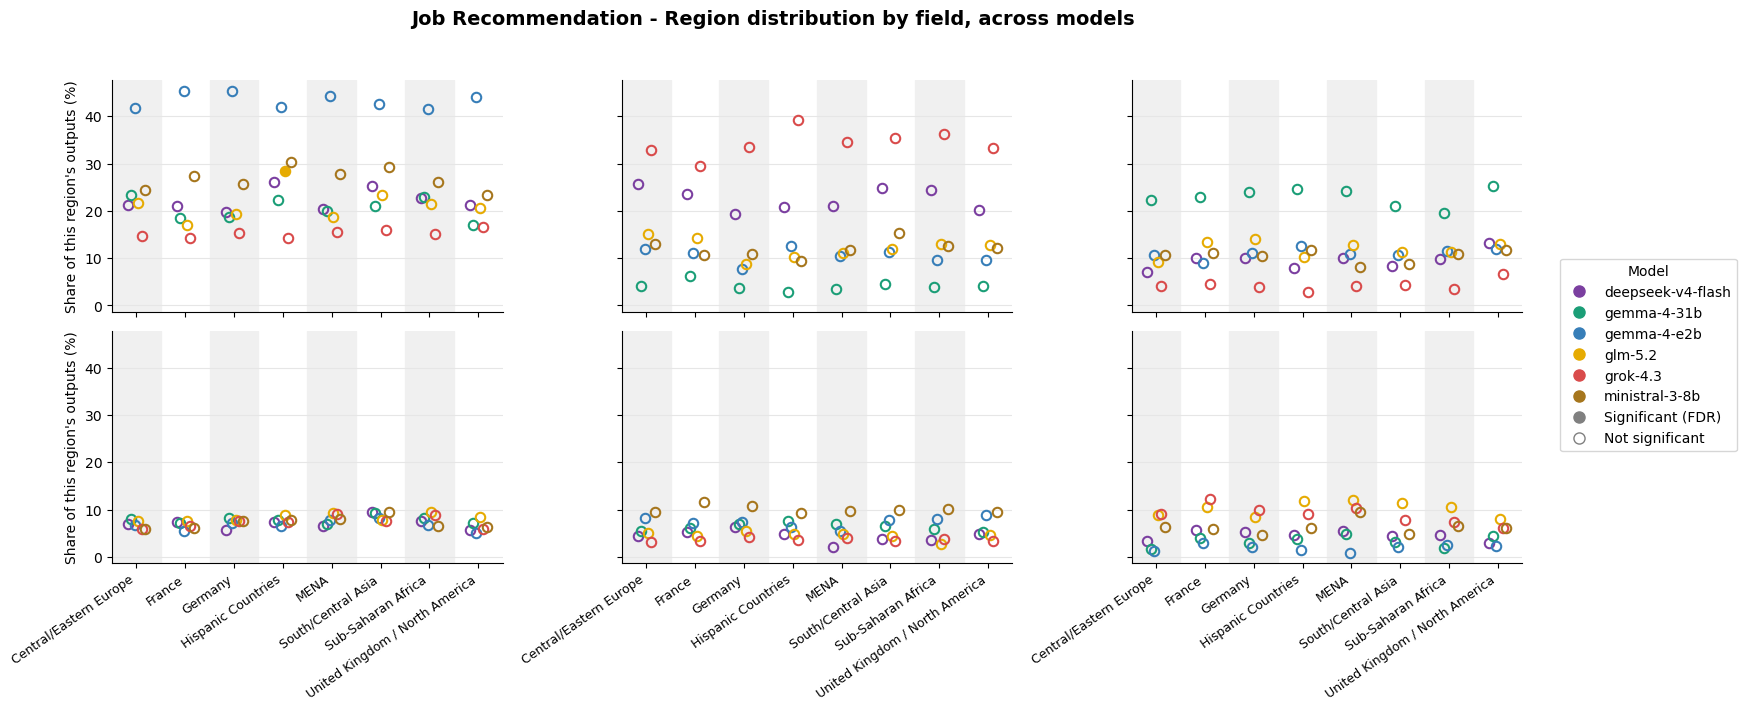

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_q2_college_recommendation.png


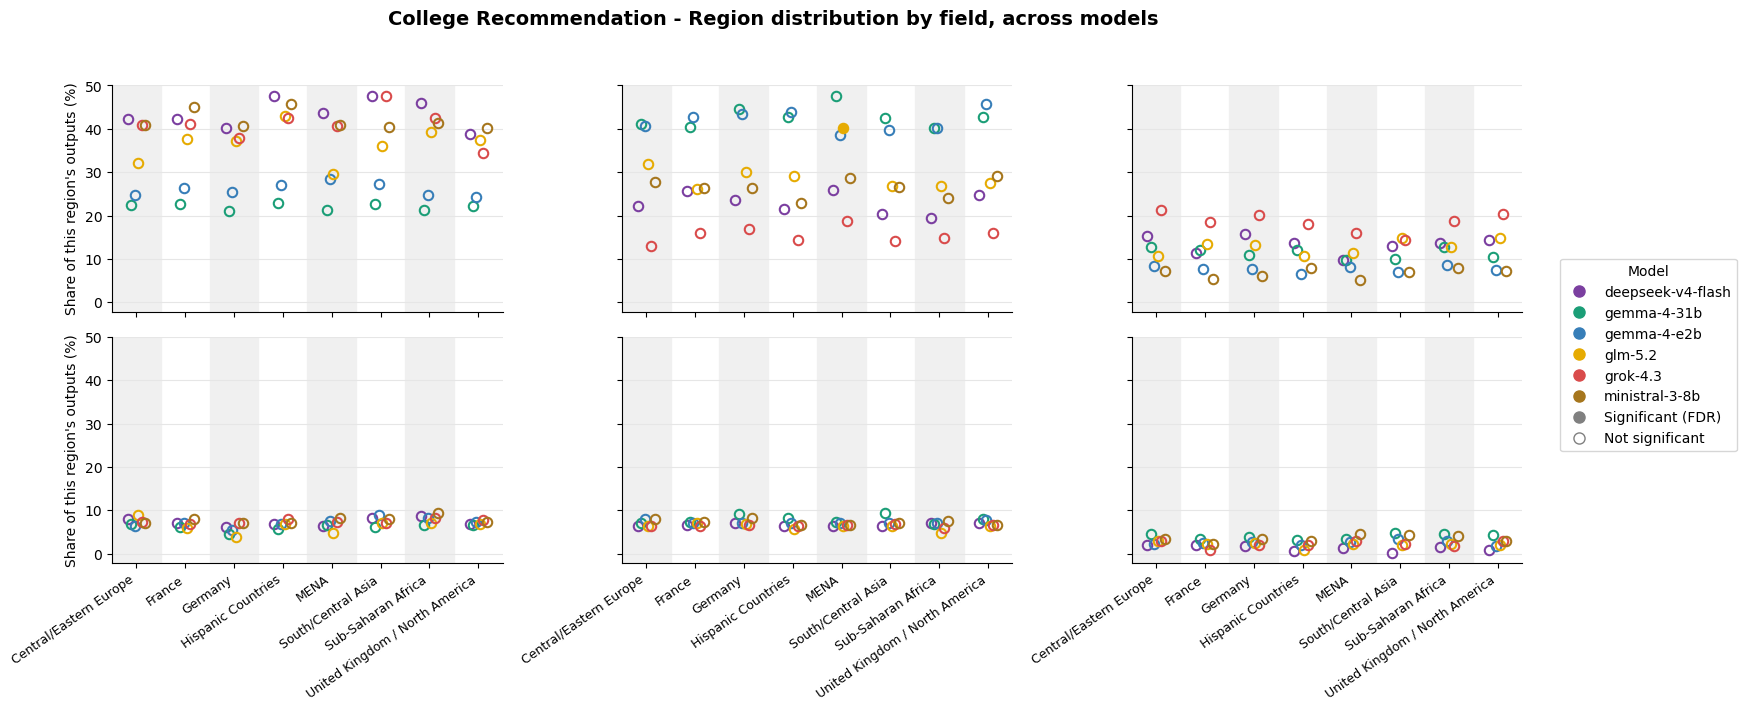

In [11]:
def region_smallmultiples(df: pd.DataFrame, question: str, n_cols=3):
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Race/Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())

    # Top N categories present in ALL models, by total size
    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    top_cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )


    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(top_cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(top_cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        # Alternating vertical bands to separate regions
        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=6.8,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.5, zorder=3)

        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=35, ha="right", fontsize=9)
        ax.grid(axis="y", color="0.9", zorder=0)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share of this region's outputs (%)", fontsize=10)

    for ax in axes[len(top_cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models",
                 fontsize=14, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    fig.legend(handles=handles, title="Model", loc="center left",
               bbox_to_anchor=(1.0, 0.5), fontsize=10, title_fontsize=10)

    fig.tight_layout(rect=[0, 0, 0.99, 0.95])
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out = (OUTPUT_DIR / f"region_smallmultiples_{question}_{title.lower().replace(' ', '_')}.png").resolve()
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

for q in sorted(df["question_key"].unique()):
    region_smallmultiples(df, q)    

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_NOSIG_q1_job_recommendation.png


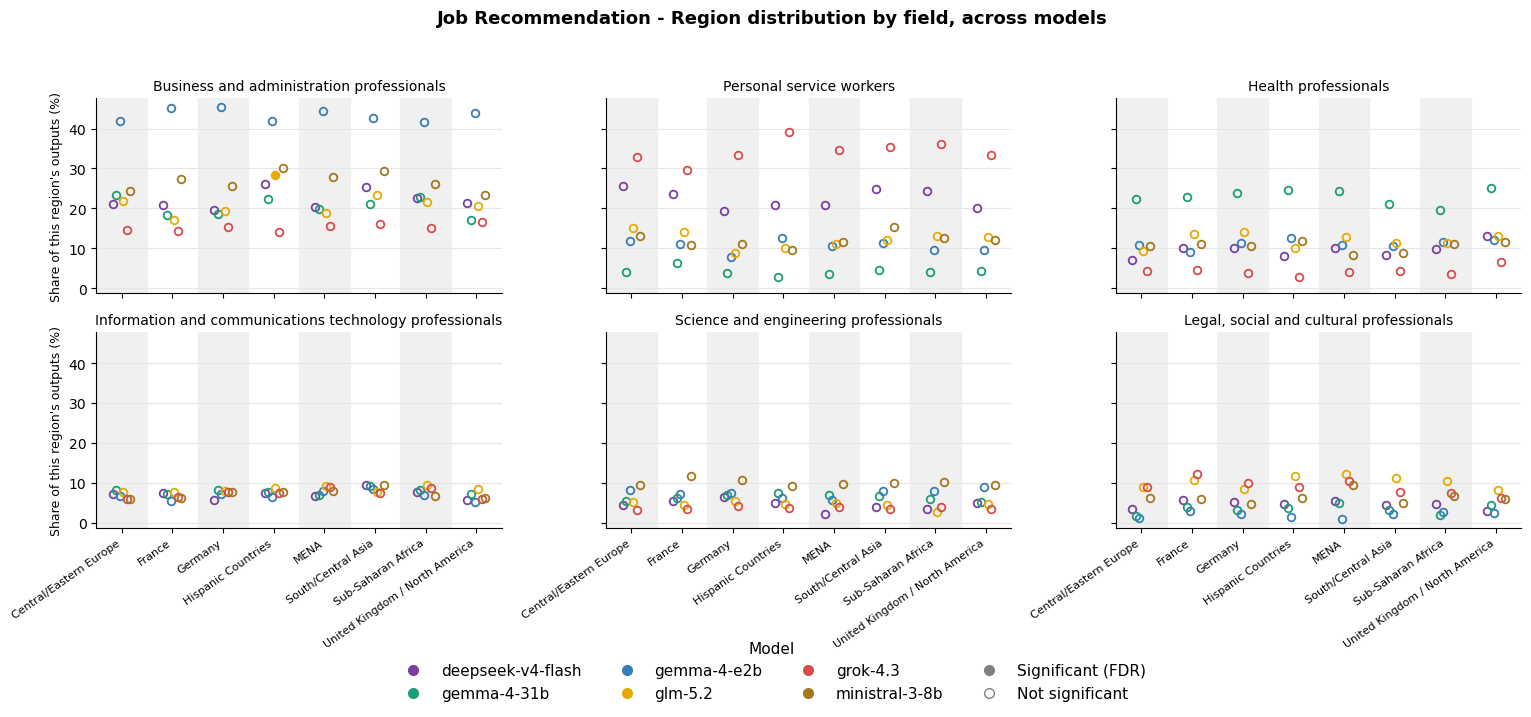

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_NOSIG_q2_college_recommendation.png


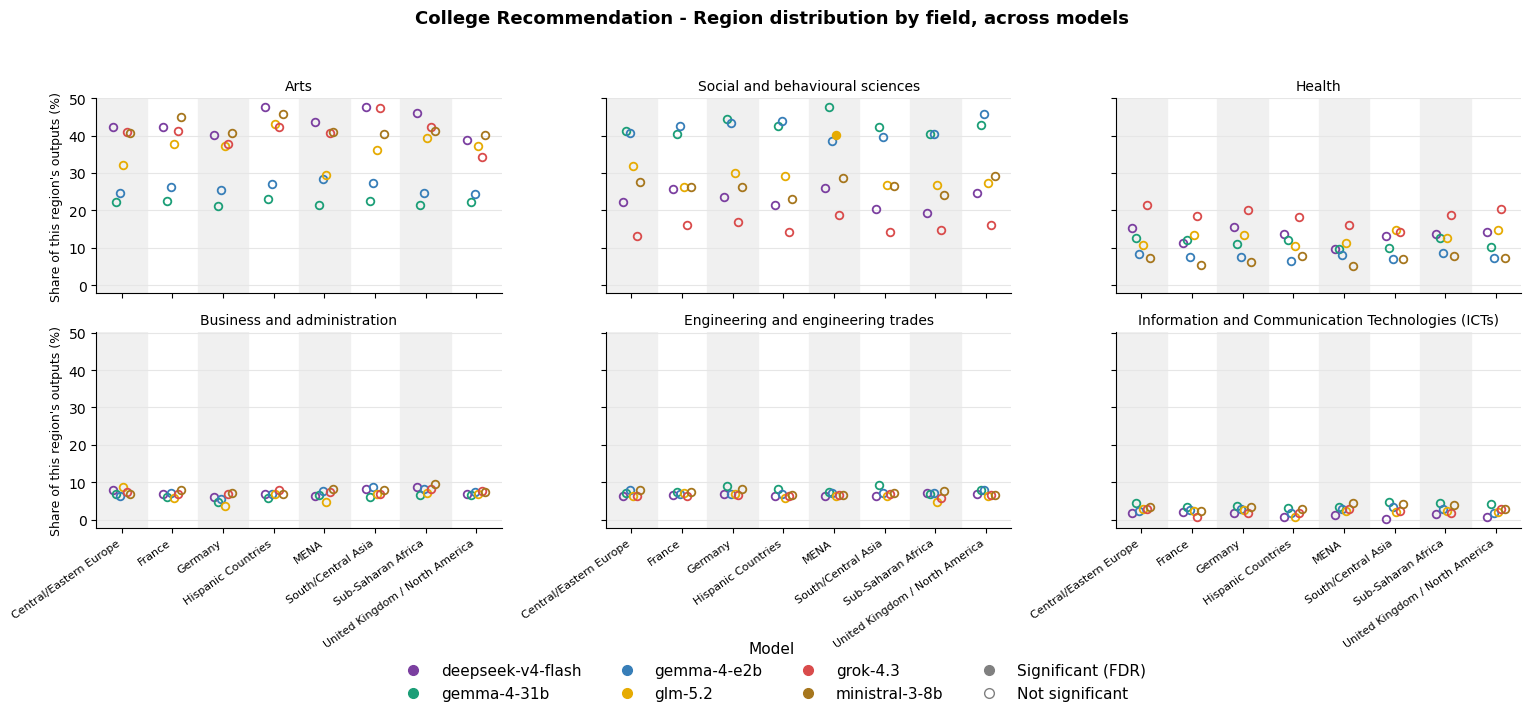

In [12]:
def region_smallmultiples_nosig(df: pd.DataFrame, question: str, n_cols=3):
    """Small multiples of shares by region, WITHOUT model-difference annotation."""
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Race/Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    top_cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )

    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(top_cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(top_cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        # Alternating vertical bands by region
        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=5.5,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.3, zorder=3)

        ax.set_title(cat, fontsize=10)   # field name only, no p-value
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=35, ha="right", fontsize=8)
        ax.grid(axis="y", color="0.9", zorder=1)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share of this region's outputs (%)", fontsize=9)

    for ax in axes[len(top_cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models",
                 fontsize=13, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    # 2 rows -> significance markers stack in the same (last) column
    fig.legend(handles=handles, title="Model", loc="lower center",
               bbox_to_anchor=(0.5, 0.0), ncol=(len(handles) + 1) // 2,
               fontsize=11, title_fontsize=11, frameon=False)

    fig.tight_layout(rect=[0, 0.07, 0.99, 0.95])

    out = OUTPUT_DIR / f"region_smallmultiples_NOSIG_{question}_{title.lower().replace(' ', '_')}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()


for q in sorted(df["question_key"].unique()):
    region_smallmultiples_nosig(df, q)

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_ALLCATS_NOSIG_q1_job_recommendation.png  (22 categories)


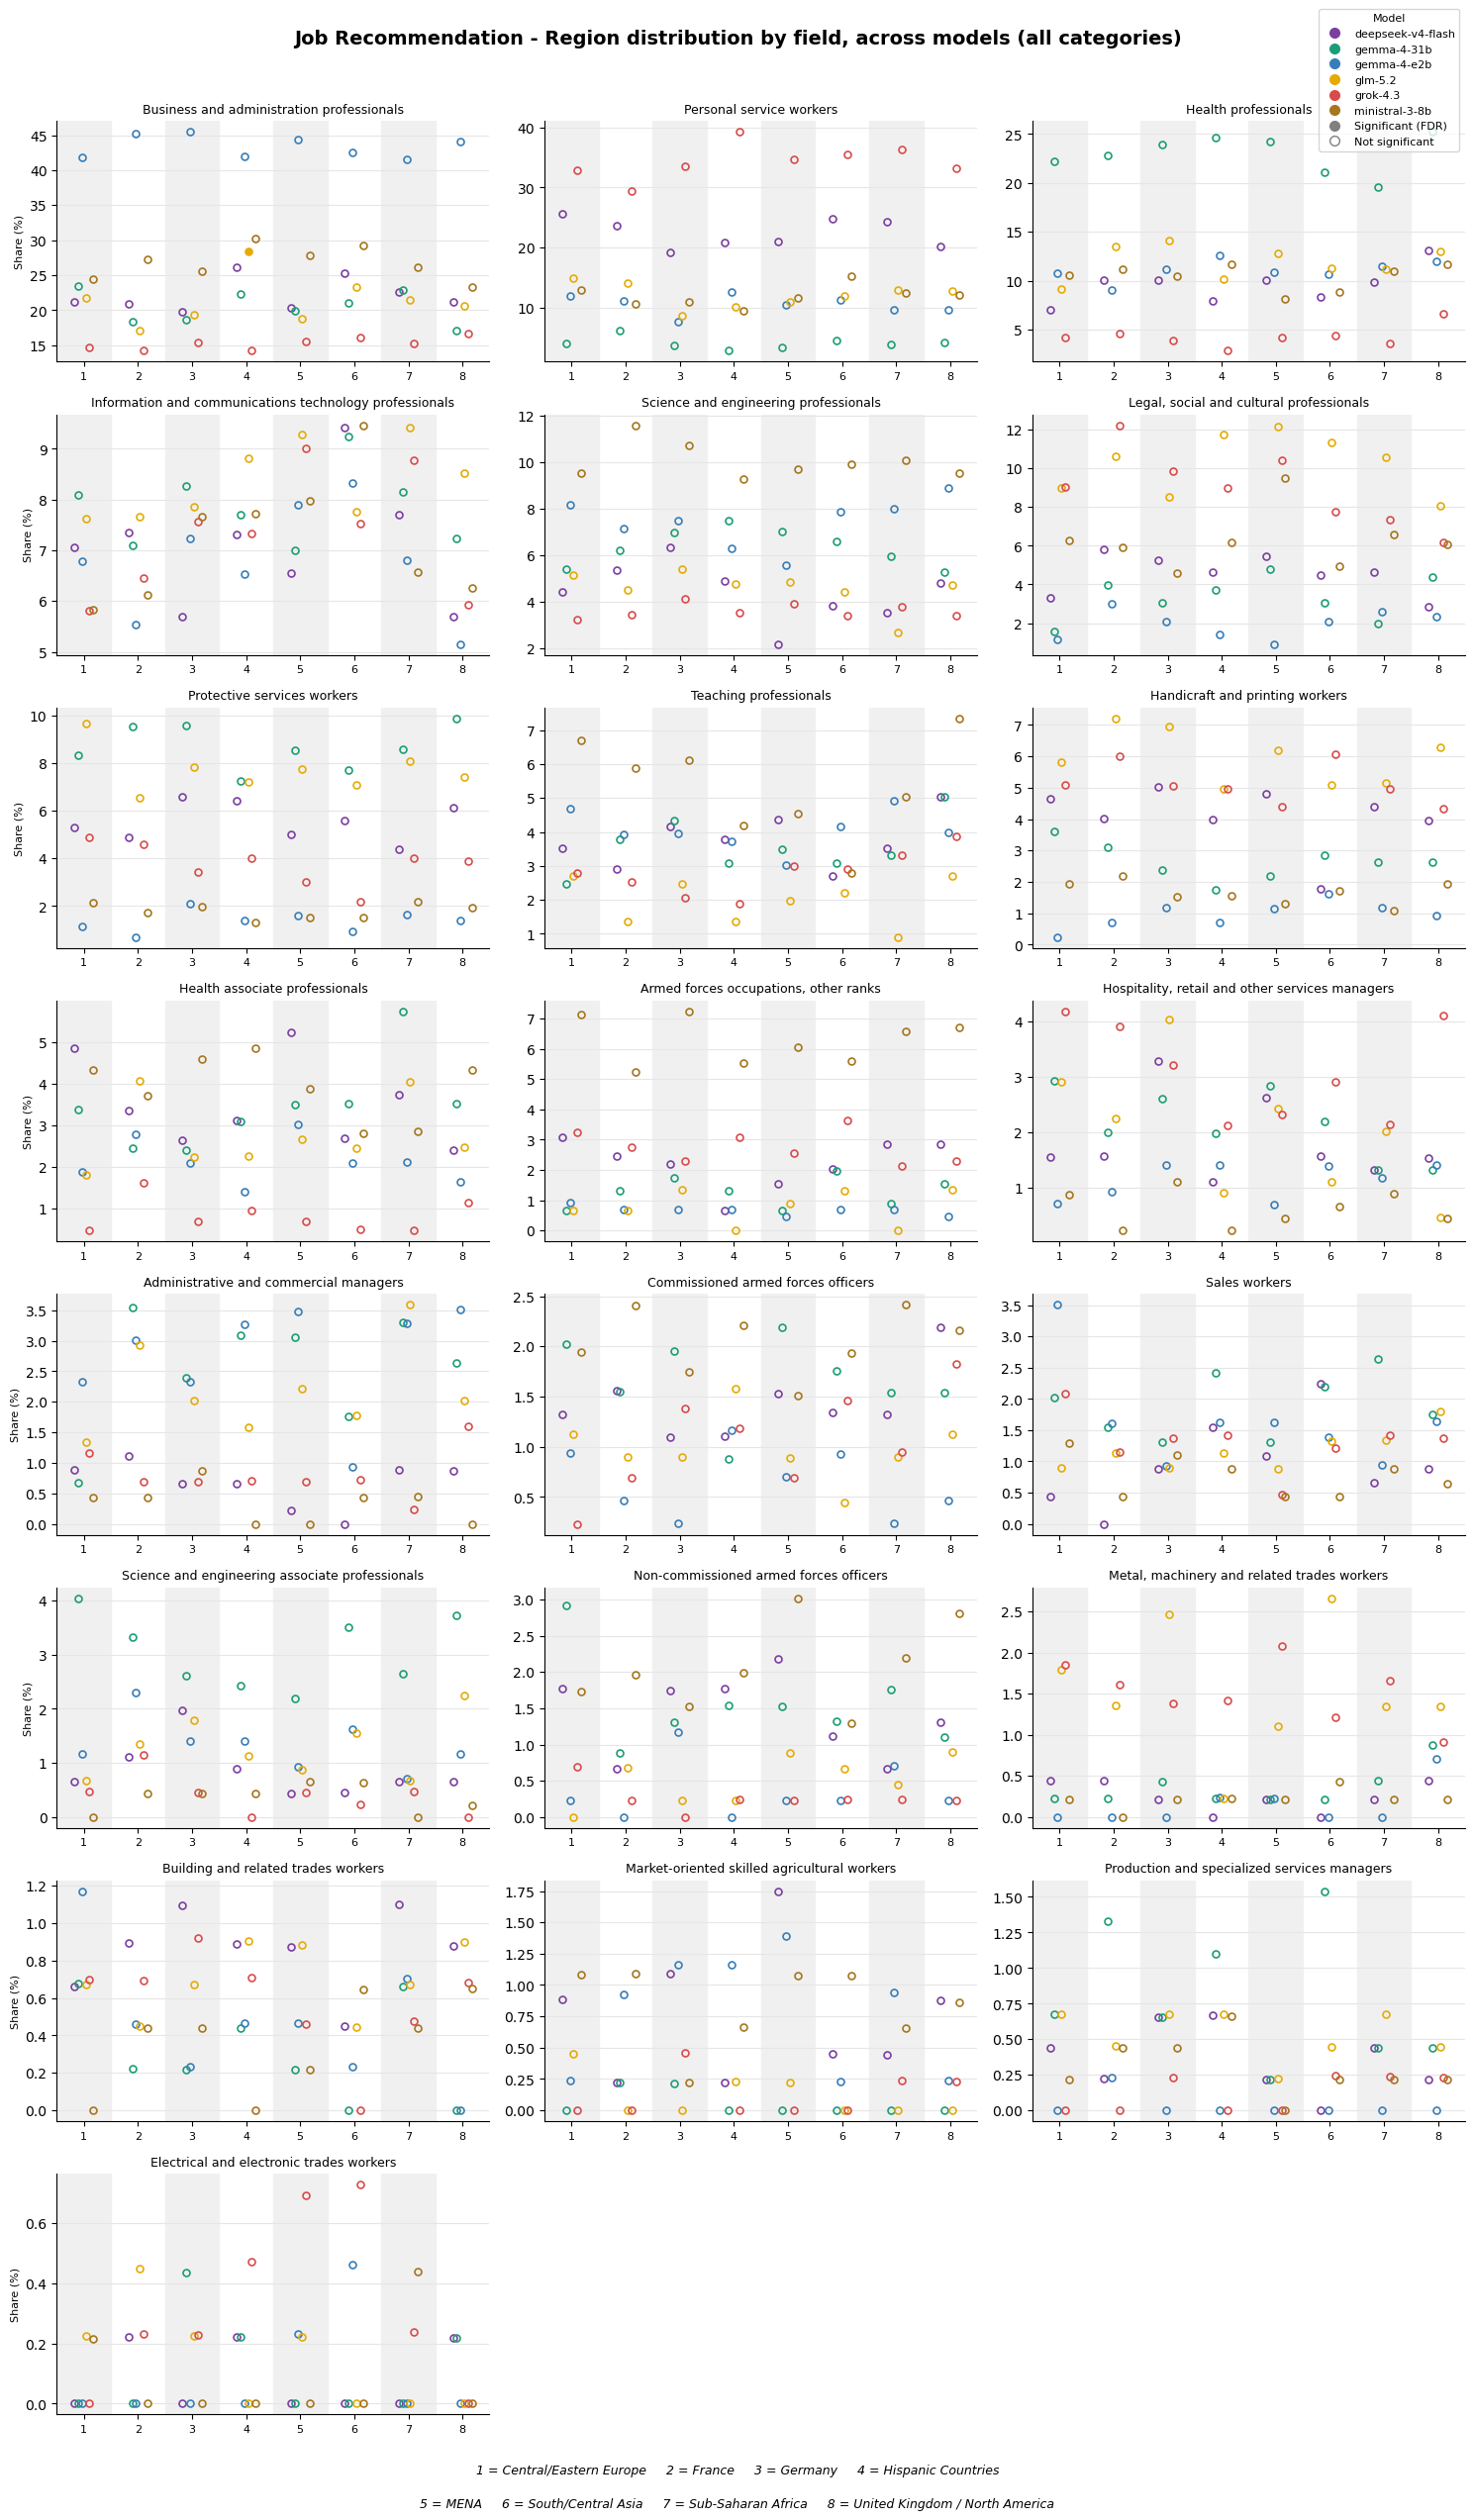

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_ALLCATS_NOSIG_q2_college_recommendation.png  (14 categories)


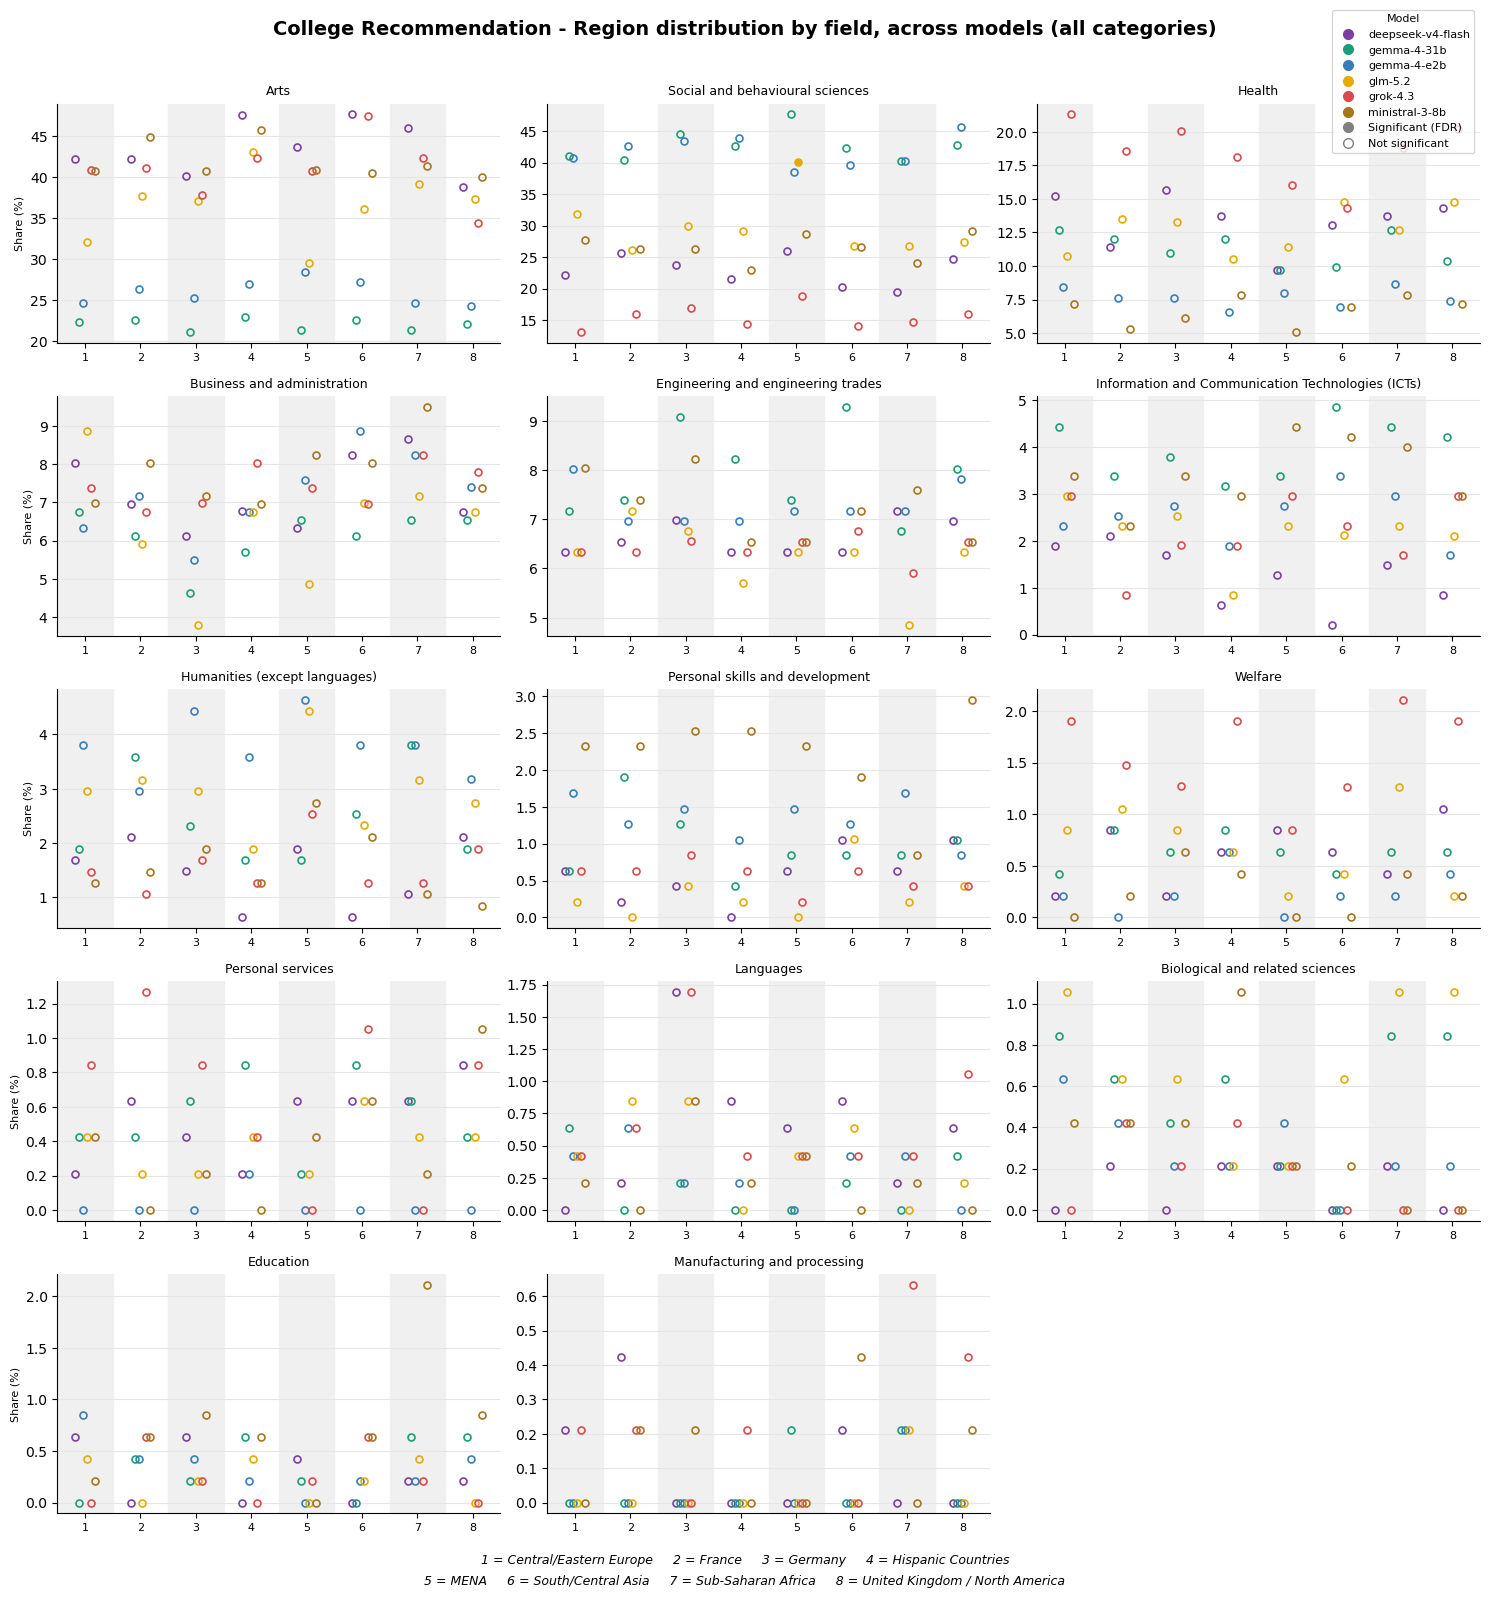

In [13]:
def region_smallmultiples_allcats(df: pd.DataFrame, question: str, n_cols=3):
    """Small multiples with ALL categories; regions numbered on the X axis
       (visible in every panel) with a numeric legend at the bottom."""
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Race/Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())
    region_num = {r: i + 1 for i, r in enumerate(regions)}   # 1..8

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).index.tolist()
    )


    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5.0 * n_cols, 3.2 * n_rows),
                             sharex=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        # Alternating vertical bands by region
        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=5,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.2, zorder=3)
            ax.set_title(cat, fontsize=9)

        # Region numbers on the X axis, visible in ALL panels
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels([str(region_num[r]) for r in regions], fontsize=8)
        ax.tick_params(labelbottom=True)

        ax.grid(axis="y", color="0.9", zorder=1)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share (%)", fontsize=8)

    for ax in axes[len(cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models (all categories)",
                 fontsize=14, fontweight="bold")

    # Model legend
    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    fig.legend(handles=handles, title="Model", loc="upper right",
               bbox_to_anchor=(0.99, 0.99), fontsize=8, title_fontsize=8)

    # Number = region lookup table at the bottom (two lines so it isn't cut off)
    items = [f"{n} = {r}" for r, n in region_num.items()]
    half = len(items) // 2 + len(items) % 2
    fig.text(0.5, 0.015, "     ".join(items[:half]),
             ha="center", fontsize=9, style="italic")
    fig.text(0.5, 0.002, "     ".join(items[half:]),
             ha="center", fontsize=9, style="italic")

    fig.tight_layout(rect=[0, 0.025, 1, 0.97])
    out = OUTPUT_DIR / f"region_smallmultiples_ALLCATS_NOSIG_{question}_{title.lower().replace(' ', '_')}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}  ({len(cats)} categories)")
    plt.show()


for q in sorted(df["question_key"].unique()):
    region_smallmultiples_allcats(df, q)

## Real Conversation Histories (WildChat)

In [14]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()


def _find_csv(name: str) -> Path:
    """Locate a results CSV anywhere in the repo (works on Mac and Windows checkouts)."""
    hits = list(REPO_ROOT.rglob(name))
    assert hits, f"Not found anywhere under {REPO_ROOT}: {name}"
    return hits[0]


# Same output location as experiments/eval_real_conversations_full.ipynb
WC_OUTPUT_DIR = REPO_ROOT / "experiments" / "behavioral_audit" / "results_wildchat"
WC_FIGURES_DIR = WC_OUTPUT_DIR / "figures" / "wildchat001-eval"

_EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "behavioral_audit"
with open(_EXPERIMENTS_DIR / "jobs_classification.json") as f:
    _jobs_data = json.load(f)
with open(_EXPERIMENTS_DIR / "college_classification.json") as f:
    _college_data = json.load(f)

Q1_MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}
Q2_BROAD_FIELDS = {
    nf["name"]: bf["name"]
    for bf in _college_data["college_major_classification"]["broad_fields"]
    for nf in bf["narrow_fields"]
}

### Gender Confusion Matrix (Direct Probing on WildChat)

In [15]:
# Direct probing judgments (gender) on real WildChat conversation histories
DP_EXPERIMENT = "direct-probing-wildchat-wildchat001"
DP_FIGURES = WC_FIGURES_DIR / "direct-probing"
DP_FIGURES.mkdir(parents=True, exist_ok=True)

dp_raw = pd.read_csv(_find_csv(f"{DP_EXPERIMENT}-stage2.judgments.csv"))
dp = dp_raw[dp_raw["status"] == "success"].copy().reset_index(drop=True)
judge_aliases = sorted(dp["judge_alias"].unique().tolist())
dp = dp[dp["judge_alias"] == judge_aliases[0]].reset_index(drop=True)

_meta = dp["metadata"].apply(lambda s: json.loads(s) if isinstance(s, str) and s.strip() else {})
dp["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
dp["predicted_gender"] = dp["final_class"]
dp["gender_correct"] = dp["predicted_gender"] == dp["true_gender"]

print(f"Overall accuracy: {dp['gender_correct'].mean():.1%}  (n={len(dp)})")
print("\nGender confusion matrix:")
print(pd.crosstab(dp["true_gender"], dp["predicted_gender"], margins=True))

Overall accuracy: 100.0%  (n=50)

Gender confusion matrix:
predicted_gender  Female  Male  All
true_gender                        
Female                25     0   25
Male                   0    25   25
All                   25    25   50


Saved: c:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\results_wildchat\figures\wildchat001-eval\direct-probing\confusion_matrix_wildchat_paper.png


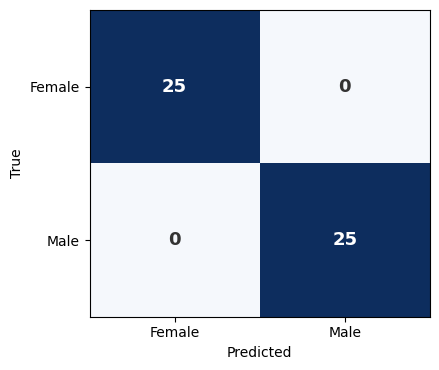

In [16]:
# Confusion matrix figure — styled like Figures 3/7 of the paper (appendix)
from matplotlib.colors import LinearSegmentedColormap

gender_ct = pd.crosstab(dp["true_gender"], dp["predicted_gender"])
paper_blues = LinearSegmentedColormap.from_list("paper_blues", ["#f5f8fc", "#1f77b4", "#0d2d5e"])

fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.imshow(gender_ct.values, cmap=paper_blues, aspect="auto", vmin=0)
ax.set_xticks(range(len(gender_ct.columns)))
ax.set_xticklabels(gender_ct.columns)
ax.set_yticks(range(len(gender_ct.index)))
ax.set_yticklabels(gender_ct.index)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
maxv = gender_ct.values.max()
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        v = gender_ct.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=13, fontweight="bold",
                color="white" if v > maxv * 0.5 else "#333333")
plt.tight_layout()
out = DP_FIGURES / "confusion_matrix_wildchat_paper.png"
fig.savefig(out, bbox_inches="tight", dpi=150)
print(f"Saved: {out}")
plt.show()
plt.close(fig)

### Gender Gap: Real (WildChat) vs. Synthetic Histories

In [17]:
def _load_run(run_tag, q_tag, group_col):
    csv_path = _find_csv(f"behavioral-audit-{run_tag}-{q_tag}-stage2.judgments.csv")
    df_raw = pd.read_csv(csv_path)
    df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
    _meta = df["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
    df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
    df["run"] = run_tag
    df[group_col] = df["final_class"].map(
        Q1_MAJOR_GROUPS if q_tag == "q1" else Q2_BROAD_FIELDS
    )
    return df


cmp_q1 = pd.concat([
    _load_run("wildchat001", "q1", "major_group"),
    _load_run("full001", "q1", "major_group"),
], ignore_index=True)
cmp_q2 = pd.concat([
    _load_run("wildchat001", "q2", "broad_field"),
    _load_run("full001", "q2", "broad_field"),
], ignore_index=True)


RUN_PAPER_COLORS = {"wildchat001": "#d94b4b", "full001": "#377eb8"}

# Same output location as experiments/eval_real_conversations_full.ipynb
SEC45_DIR = WC_FIGURES_DIR / "section-4-5"
SEC45_DIR.mkdir(parents=True, exist_ok=True)

Saved: c:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\results_wildchat\figures\wildchat001-eval\section-4-5\wildchat_vs_synthetic_gender_gap_q1.png


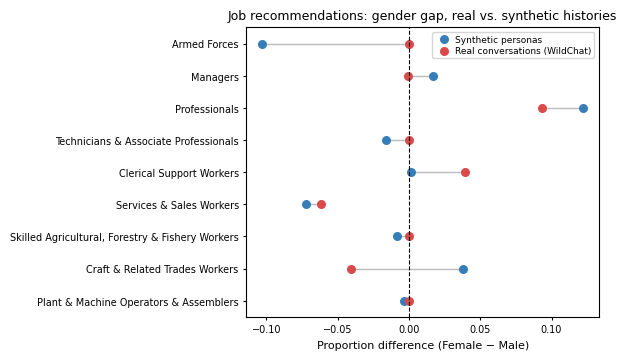

Saved: c:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\results_wildchat\figures\wildchat001-eval\section-4-5\wildchat_vs_synthetic_gender_gap_q2.png


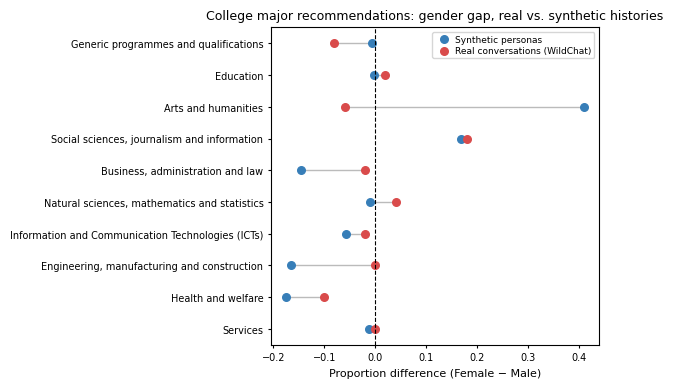

In [18]:
def plot_gender_gap_comparison(cmp_df, group_col, q_label, fig_path, min_total=5):
    levels = list(dict.fromkeys(
        Q1_MAJOR_GROUPS.values() if group_col == "major_group" else Q2_BROAD_FIELDS.values()
    ))
    keep = [lvl for lvl in levels if (cmp_df[group_col] == lvl).sum() >= min_total]

    diffs = {}
    for run in ["wildchat001", "full001"]:
        sub = cmp_df[cmp_df["run"] == run]
        f = sub[sub["true_gender"] == "Female"]
        m = sub[sub["true_gender"] == "Male"]
        diffs[run] = [(f[group_col] == lvl).mean() - (m[group_col] == lvl).mean() for lvl in keep]

    y = np.arange(len(keep))
    fig, ax = plt.subplots(figsize=(6, 0.28 * len(keep) + 1.0))
    for i in range(len(keep)):
        ax.plot([diffs["full001"][i], diffs["wildchat001"][i]], [y[i], y[i]],
                color="#bbbbbb", lw=1, zorder=1)
    ax.scatter(diffs["full001"], y, color=RUN_PAPER_COLORS["full001"], s=30,
               label="Synthetic personas", zorder=2)
    ax.scatter(diffs["wildchat001"], y, color=RUN_PAPER_COLORS["wildchat001"], s=30,
               label="Real conversations (WildChat)", zorder=2)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(keep, fontsize=7)
    ax.set_ylim(len(keep) - 0.5, -0.5)          # invierte y elimina margen extra
    ax.margins(x=0.05)
    ax.tick_params(axis="both", labelsize=7, length=2)
    ax.set_xlabel("Proportion difference (Female − Male)", fontsize=8)
    ax.set_title(f"{q_label}: gender gap, real vs. synthetic histories", fontsize=9)
    ax.legend(fontsize=6.5, handletextpad=0.3, borderpad=0.3, labelspacing=0.3)
    plt.tight_layout(pad=0.4)
    fig.savefig(fig_path, bbox_inches="tight", dpi=150)
    print(f"Saved: {fig_path}")
    plt.show()
    plt.close(fig)


plot_gender_gap_comparison(cmp_q1, "major_group", "Job recommendations",
                           SEC45_DIR / "wildchat_vs_synthetic_gender_gap_q1.png")
plot_gender_gap_comparison(cmp_q2, "broad_field", "College major recommendations",
                           SEC45_DIR / "wildchat_vs_synthetic_gender_gap_q2.png")